In [1]:
from sklearn.metrics import roc_auc_score
import math
import pandas as pd

In [2]:
Demo = pd.read_csv("crx.data")

In [3]:
Demo 

,b,30.83,0,u,g,w,v,1.25,t,t.1,01,f,g.1,00202,0.1,+
0,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,00043,560,+
1,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,00280,824,+
2,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,00100,3,+
3,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,00120,0,+
4,b,32.08,4.000,u,g,m,v,2.50,t,f,0,t,g,00360,0,+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
684,b,21.08,10.085,y,p,e,h,1.25,f,f,0,f,g,00260,0,-
685,a,22.67,0.750,u,g,c,v,2.00,f,t,2,t,g,00200,394,-
686,a,25.25,13.500,y,p,ff,ff,2.00,f,t,1,t,g,00200,1,-
687,b,17.92,0.205,u,g,aa,v,0.04,f,f,0,f,g,00280,750,-


In [4]:
# Defining column names
column_names = [
    'A1', 'A2', 'A3', 'A4', 'A5',
    'A6', 'A7', 'A8', 'A9', 'A10',
    'A11', 'A12', 'A13', 'A14', 'A15',
    'Class'
]

# Reload the dataset correctly
Demo = pd.read_csv(
    "crx.data",
    header=None,
    names=column_names
)

# Display the first five rows
Demo.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,Class
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,00202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,00043,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,00280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,00100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,00120,0,+


In [5]:
Demo.shape

(690, 16)

In [6]:
# Saving DataFrame as a CSV file
Demo.to_csv("credit_approval.csv", index=False)

print("Dataset saved successfully.")

Dataset saved successfully.


In [7]:
Demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      690 non-null    object 
 1   A2      690 non-null    object 
 2   A3      690 non-null    float64
 3   A4      690 non-null    object 
 4   A5      690 non-null    object 
 5   A6      690 non-null    object 
 6   A7      690 non-null    object 
 7   A8      690 non-null    float64
 8   A9      690 non-null    object 
 9   A10     690 non-null    object 
 10  A11     690 non-null    int64  
 11  A12     690 non-null    object 
 12  A13     690 non-null    object 
 13  A14     690 non-null    object 
 14  A15     690 non-null    int64  
 15  Class   690 non-null    object 
dtypes: float64(2), int64(2), object(12)
memory usage: 86.4+ KB


In [8]:
Demo.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,Class
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,00202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,00043,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,00280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,00100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,00120,0,+


In [9]:
Demo.tail()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,Class
685,b,21.08,10.085,y,p,e,h,1.25,f,f,0,f,g,00260,0,-
686,a,22.67,0.750,u,g,c,v,2.00,f,t,2,t,g,00200,394,-
687,a,25.25,13.500,y,p,ff,ff,2.00,f,t,1,t,g,00200,1,-
688,b,17.92,0.205,u,g,aa,v,0.04,f,f,0,f,g,00280,750,-
689,b,35.00,3.375,u,g,c,h,8.29,f,f,0,t,g,00000,0,-


In [10]:
# Count '?' values in each column (missing values)
(Demo == '?').sum()

A1       12
A2       12
A3        0
A4        6
A5        6
A6        9
A7        9
A8        0
A9        0
A10       0
A11       0
A12       0
A13       0
A14      13
A15       0
Class     0
dtype: int64

In [11]:
# Total number of missing values represented by '?'
(Demo == '?').sum().sum()

np.int64(67)

In [12]:
import numpy as np

In [13]:
# Replace '?' with proper NumPy missing values
Demo.replace('?', np.nan, inplace=True)

In [14]:
Demo.isnull().sum()

A1       12
A2       12
A3        0
A4        6
A5        6
A6        9
A7        9
A8        0
A9        0
A10       0
A11       0
A12       0
A13       0
A14      13
A15       0
Class     0
dtype: int64

In [15]:
Demo.isnull().sum()

A1       12
A2       12
A3        0
A4        6
A5        6
A6        9
A7        9
A8        0
A9        0
A10       0
A11       0
A12       0
A13       0
A14      13
A15       0
Class     0
dtype: int64

In [16]:
print("Total missing values:", Demo.isnull().sum().sum())

Total missing values: 67


In [17]:
Demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      678 non-null    object 
 1   A2      678 non-null    object 
 2   A3      690 non-null    float64
 3   A4      684 non-null    object 
 4   A5      684 non-null    object 
 5   A6      681 non-null    object 
 6   A7      681 non-null    object 
 7   A8      690 non-null    float64
 8   A9      690 non-null    object 
 9   A10     690 non-null    object 
 10  A11     690 non-null    int64  
 11  A12     690 non-null    object 
 12  A13     690 non-null    object 
 13  A14     677 non-null    object 
 14  A15     690 non-null    int64  
 15  Class   690 non-null    object 
dtypes: float64(2), int64(2), object(12)
memory usage: 86.4+ KB


In [18]:
# Convert A2 and A14 to numerical data types
Demo['A2'] = pd.to_numeric(Demo['A2'], errors='coerce')
Demo['A14'] = pd.to_numeric(Demo['A14'], errors='coerce')

# Check the updated data types
Demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      678 non-null    object 
 1   A2      678 non-null    float64
 2   A3      690 non-null    float64
 3   A4      684 non-null    object 
 4   A5      684 non-null    object 
 5   A6      681 non-null    object 
 6   A7      681 non-null    object 
 7   A8      690 non-null    float64
 8   A9      690 non-null    object 
 9   A10     690 non-null    object 
 10  A11     690 non-null    int64  
 11  A12     690 non-null    object 
 12  A13     690 non-null    object 
 13  A14     677 non-null    float64
 14  A15     690 non-null    int64  
 15  Class   690 non-null    object 
dtypes: float64(4), int64(2), object(10)
memory usage: 86.4+ KB


In [19]:
# Define numerical and categorical columns
numerical_columns = ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']

categorical_columns = [
    'A1', 'A4', 'A5', 'A6', 'A7',
    'A9', 'A10', 'A12', 'A13'
]

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['A2', 'A3', 'A8', 'A11', 'A14', 'A15']

Categorical columns:
['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13']


In [20]:
# Generate descriptive statistics for numerical variables
Demo[numerical_columns].describe()

,A2,A3,A8,A11,A14,A15
count,678.000000,690.000000,690.000000,690.00000,677.000000,690.000000
mean,31.568171,4.758725,2.223406,2.40000,184.014771,1017.385507
std,11.957862,4.978163,3.346513,4.86294,173.806768,5210.102598
min,13.750000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,22.602500,1.000000,0.165000,0.00000,75.000000,0.000000
50%,28.460000,2.750000,1.000000,0.00000,160.000000,5.000000
75%,38.230000,7.207500,2.625000,3.00000,276.000000,395.500000
max,80.250000,28.000000,28.500000,67.00000,2000.000000,100000.000000


In [21]:
# Display the number of unique values in each categorical variable
for column in categorical_columns:
    print(f"{column}: {Demo[column].nunique()} unique values")

A1: 2 unique values
A4: 3 unique values
A5: 3 unique values
A6: 14 unique values
A7: 9 unique values
A9: 2 unique values
A10: 2 unique values
A12: 2 unique values
A13: 3 unique values


In [22]:
# Display frequency counts for categorical variables
for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(Demo[column].value_counts(dropna=False))


--- A1 ---
A1
b      468
a      210
NaN     12
Name: count, dtype: int64

--- A4 ---
A4
u      519
y      163
NaN      6
l        2
Name: count, dtype: int64

--- A5 ---
A5
g      519
p      163
NaN      6
gg       2
Name: count, dtype: int64

--- A6 ---
A6
c      137
q       78
w       64
i       59
aa      54
ff      53
k       51
cc      41
m       38
x       38
d       30
e       25
j       10
NaN      9
r        3
Name: count, dtype: int64

--- A7 ---
A7
v      399
h      138
bb      59
ff      57
NaN      9
j        8
z        8
dd       6
n        4
o        2
Name: count, dtype: int64

--- A9 ---
A9
t    361
f    329
Name: count, dtype: int64

--- A10 ---
A10
f    395
t    295
Name: count, dtype: int64

--- A12 ---
A12
f    374
t    316
Name: count, dtype: int64

--- A13 ---
A13
g    625
s     57
p      8
Name: count, dtype: int64


In [23]:
# Count the number of observations in each class
Demo['Class'].value_counts()

Class
-    383
+    307
Name: count, dtype: int64

In [24]:
# class distribution as percentages
Demo['Class'].value_counts(normalize=True) * 100

Class
-    55.507246
+    44.492754
Name: proportion, dtype: float64

In [26]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
summarize)
from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import \
(LinearDiscriminantAnalysis as LDA,
QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

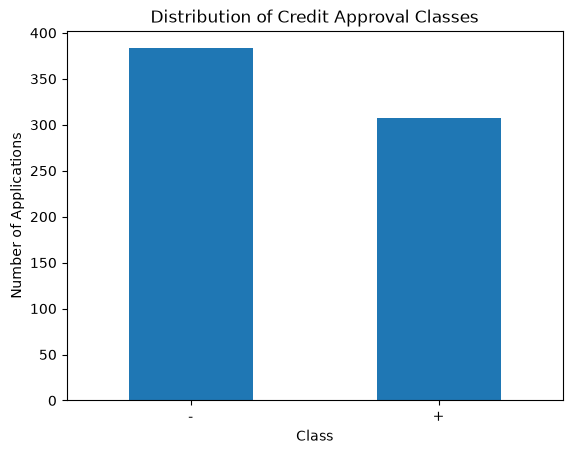

In [27]:
# Visualize the distribution of the target class
from matplotlib import pyplot as plt


Demo['Class'].value_counts().plot(kind='bar')

plt.title('Distribution of Credit Approval Classes')
plt.xlabel('Class')
plt.ylabel('Number of Applications')
plt.xticks(rotation=0)
plt.show()

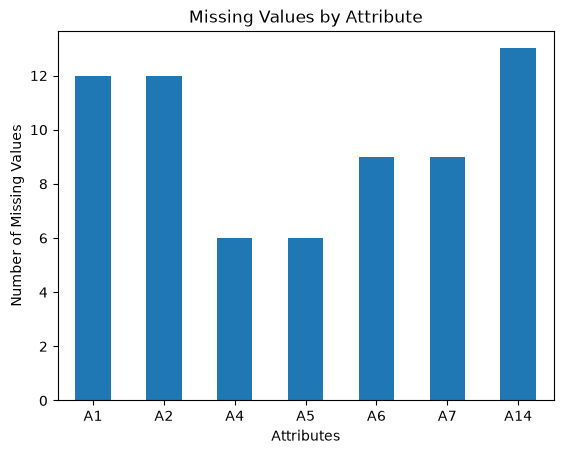

In [28]:
# Calculate missing values per column
missing_values = Demo.isnull().sum()

# Keep only columns that contain missing values
missing_values = missing_values[missing_values > 0]

# Plot missing values
missing_values.plot(kind='bar')

plt.title('Missing Values by Attribute')
plt.xlabel('Attributes')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=0)
plt.show()

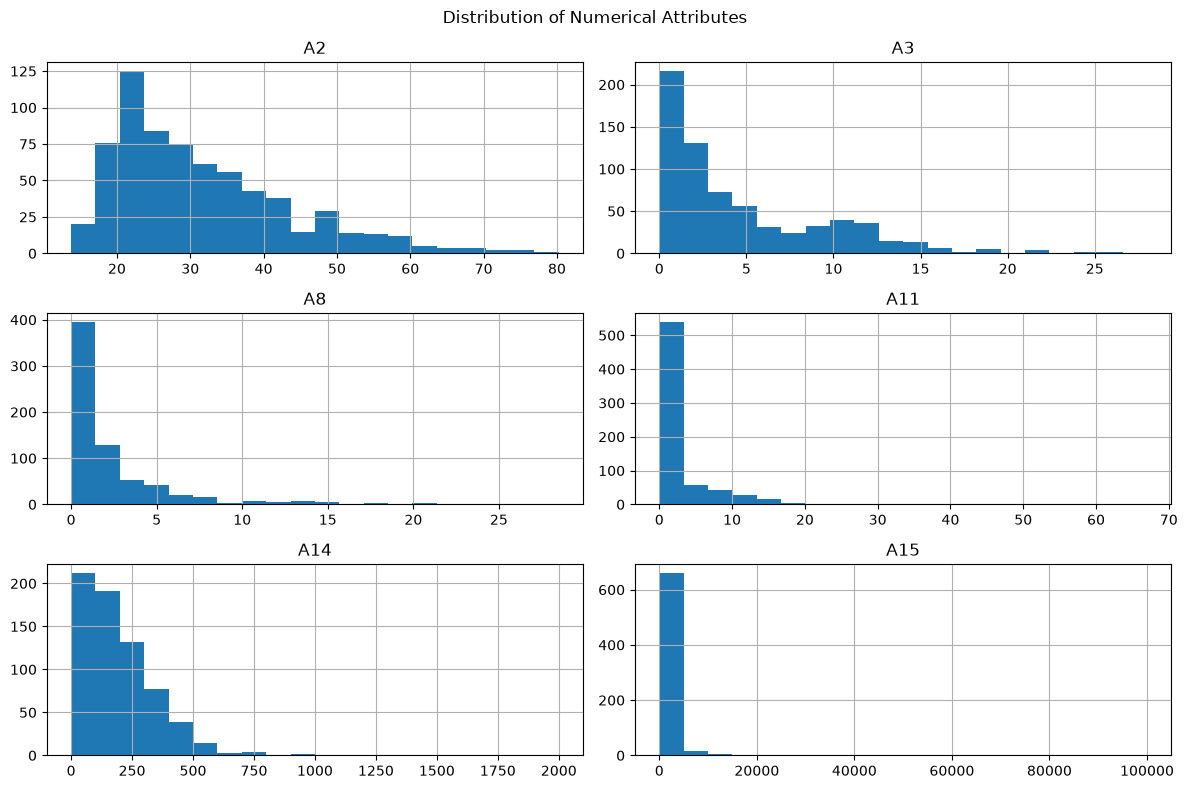

In [29]:
# Plot histograms for numerical attributes
Demo[numerical_columns].hist(figsize=(12, 8), bins=20)

plt.suptitle('Distribution of Numerical Attributes')
plt.tight_layout()
plt.show()

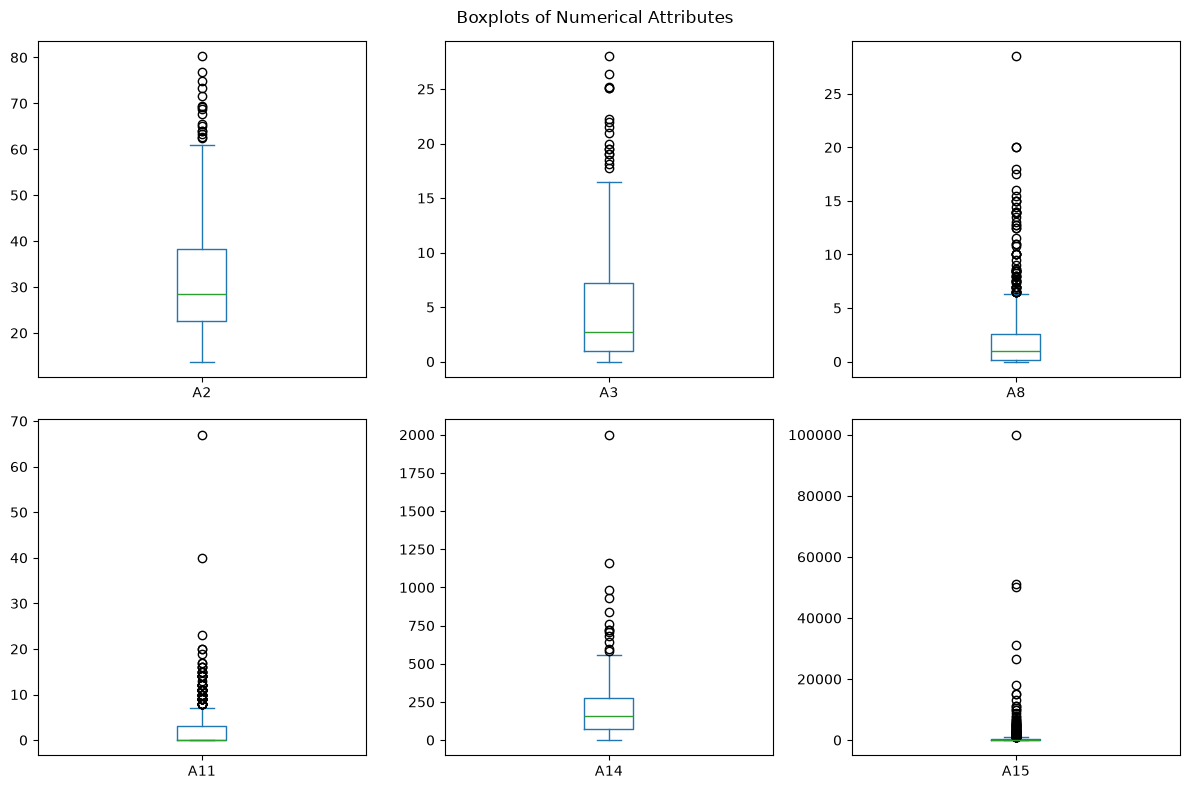

In [30]:
# Create boxplots for numerical variables
Demo[numerical_columns].plot(
    kind='box',
    subplots=True,
    layout=(2, 3),
    figsize=(12, 8)
)

plt.suptitle('Boxplots of Numerical Attributes')
plt.tight_layout()
plt.show()

In [31]:
# Detect potential outliers using the IQR method
for column in numerical_columns:
    
    Q1 = Demo[column].quantile(0.25)
    Q3 = Demo[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = Demo[
        (Demo[column] < lower_bound) |
        (Demo[column] > upper_bound)
    ]
    
    print(f"{column}: {len(outliers)} potential outliers")

A2: 16 potential outliers
A3: 17 potential outliers
A8: 63 potential outliers
A11: 79 potential outliers
A14: 13 potential outliers
A15: 113 potential outliers


In [32]:
# Summary of missing values
missing_summary = pd.DataFrame({
    'Missing Values': Demo.isnull().sum(),
    'Percentage (%)': (Demo.isnull().sum() / len(Demo)) * 100
})

missing_summary[missing_summary['Missing Values'] > 0]

,Missing Values,Percentage (%)
A1,12,1.739130
A2,12,1.739130
A4,6,0.869565
A5,6,0.869565
A6,9,1.304348
A7,9,1.304348
A14,13,1.884058


In [33]:
# Separate the input features from the target variable
X = Demo.drop('Class', axis=1)
y = Demo['Class']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (690, 15)
Target shape: (690,)


In [35]:
# Encode the target variable
y = y.map({
    '+': 1,
    '-': 0
})

# Check the encoded classes
y.value_counts()

Series([], Name: count, dtype: int64)

In [36]:
# Identify numerical and categorical variables
numerical_features = [
    'A2', 'A3', 'A8', 'A11', 'A14', 'A15'
]

categorical_features = [
    'A1', 'A4', 'A5', 'A6', 'A7',
    'A9', 'A10', 'A12', 'A13'
]

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']
Categorical features: ['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13']


In [39]:
print(Demo['Class'].unique())
print(Demo['Class'].value_counts(dropna=False))

['+' '-']
Class
-    383
+    307
Name: count, dtype: int64


In [40]:
# Remove any accidental spaces from the Class values
Demo['Class'] = Demo['Class'].astype(str).str.strip()

# Encode target variable
y = Demo['Class'].map({
    '+': 1,
    '-': 0
})

# Recreate the feature dataset
X = Demo.drop('Class', axis=1)

# Check whether y contains missing values
print("Missing values in y:", y.isnull().sum())

# Check encoded target values
print(y.value_counts(dropna=False))

Missing values in y: 0
Class
0    383
1    307
Name: count, dtype: int64


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training records: 552
Testing records: 138

Training class distribution:
Class
0    306
1    246
Name: count, dtype: int64

Testing class distribution:
Class
0    77
1    61
Name: count, dtype: int64


In [42]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [43]:
# Numerical preprocessing
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

In [44]:
# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [45]:
# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)